In [68]:
from astropy.table import Table, join

from tqdm import tqdm
from astropy import units as u

import numpy as np

import matplotlib.pyplot as plt
from astropy.constants import c

In [69]:
loa_rotvel = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_rotvel_curvefit.fits')
loa_rotvel[:5]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_RR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,VI,deproj_dist,deproj_r26,manual_VI,rot_vel_filing,r_kpc,chi2_reduced,vmax_fit,rturn_fit,vmax_err,rturn_err
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64
169678387281926,1430874,257.7495971,56.9324928,0.028921517883227336,0.028921517883227336,0,121857.89663615823,0.003250448915035935,0.31250071154567677,6.557606220245361,206.22810010342067,199.6704938831753,1,2.4024789259983957e-05,3.0,182.8750198451699,11.489101308260244,2.401212431981059e-05,0,0.008096415535868652,0.7783957484224773,0,0,0.20122416188287864,0.38706405138543304,188.0016333989227,0.004035780336833629,145.11961827963177,4.09983872988525
243323033878571,631434,151.0147419137485,1.6331543609904198,1.3809988331159857,1.3809988331159857,4,0.7242707014083862,0.0057124407591539585,0.9175586924842383,51.69132614135742,32.48938717521324,19.201938966144183,1,5.5595100500533275e-05,8.0,472239.65646196203,24.11477245431036,1.7258340278094598e-05,0,0.006601088916040368,1.0602974753074295,0,0,0.26035704174416274,--,--,--,145.11961827963177,4.09983872988525
1004815400304641,188925,193.6701,28.93758,0.0082724267277799,0.0082724267277799,0,20781.262633197082,0.0009923137447555642,0.026284859154548004,48.5860481262207,146.26021571620655,97.67416758998584,2,2.3542643581428787e-05,31.0,-181.63274387448345,72.81809787647651,1.6648346838273807e-05,0,0.0011151277859353821,0.02953801350383857,0,0,0.008088028889852567,5.63436883524322,170.25925589571688,0.03525810913705583,145.11961827963177,4.09983872988525
1005093910478848,1309576,234.30175,43.3014166667,0.019607169071382585,0.019607169071382585,0,21025.242969959974,0.004020441905483598,0.2179634595949638,134.6117401123047,320.7967839323471,186.18504382004244,1,2.380730399661915e-05,8.0,173.70559603525007,12.904304444072334,2.3796769180937358e-05,0,0.005374691904048404,0.2913825069989467,0,0,0.08955195966842268,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525
1005093910478849,1309576,234.303916667,43.2961944444,0.0190429075748926,0.0190429075748926,0,37842.76546475291,0.0023170693385198464,0.12561714881549862,134.6117401123047,204.59833750241611,69.98659739011143,1,2.3794128780331918e-05,8.0,-126.47090634603123,37.70665102866408,2.3796769180937358e-05,0,0.0031473131687750006,0.1706278271946506,0,0,0.05243985459735577,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525


In [72]:
SGA_cig = Table.read('/pscratch/sd/d/dbustos/rot_curves/sga_xmatch.fits')
SGA_cig[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,MASS_CG_5,MASSERR_CG_5
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,solMass,solMass
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0,--,--
3,SGA-2020 3,P

In [75]:
SGA_HI = Table.read('/pscratch/sd/d/dbustos/rot_curves/sga_xmatch_HI.fits')
SGA_HI = SGA_HI['SGA_ID', 'ALFALFA_AGCNr', 'logMH_alf', 'siglogMH_alf']
SGA_HI[:5]

SGA_ID,ALFALFA_AGCNr,logMH_alf,siglogMH_alf
int64,int64,float64,float64
25,250161,9.85,0.05
78,195330,9.81,0.05
141,251557,9.89,0.05
220,741161,9.27,0.07
242,242514,9.2,0.07


In [77]:
SGA = join(SGA_cig, SGA_HI, join_type = 'outer', keys = 'SGA_ID')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,MASS_CG_5,MASSERR_CG_5,ALFALFA_AGCNr,logMH_alf,siglogMH_alf
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,solMass,solMass,,,
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,int64,float64,float64
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.2

In [78]:
new_table = loa_rotvel[np.isfinite(loa_rotvel['vmax_fit']) & np.isfinite(loa_rotvel['vmax_err'])]

In [79]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

In [63]:
G = 4.30091e-6

#Reduced Hubble Constant (km/s/Mpc)
H0 = 100 * u.km / u.s / u.Mpc

Note that the mass errors still need to be added

In [80]:
new_table['l10_mass'] = np.nan
SGA['total_mass'] = np.nan
SGA['log_cgmass'] = np.nan

for i in tqdm(np.unique(new_table['SGA_ID'])):

    fibers = new_table['SGA_ID'] == i

    sga_id = SGA_dict[i]

    targs = new_table[fibers]
    
    vmax = targs['vmax_fit'][0]

    rturn = targs['rturn_fit'][0]

    r26_dist = .5 * SGA[sga_id]['D26']
    
    # distance from us to center of galaxy
    d_center = (SGA['Z_LEDA'][sga_id] * c)/H0

    # convert deprojected dist from arcmin to radians
    theta = np.radians(r26_dist/60)

    # real distance from center of galaxy to fiber in units kpc/h
    r_fiber = (d_center * np.tan(theta) * 1000).value
    
    # get vrot from fit params
    v_rot = vmax * np.tanh(r_fiber/rturn)
    
    #total mass and log total mass
    mass = (v_rot**2)*(r_fiber)/G
    
    log_mass = np.log10(mass)

    # stellar mass
    cg_mass = SGA['MASS_CG_5'][sga_id]
    log_cg =  np.log10(cg_mass)

    # HI mass
    HI_mass = SGA['logMH_alf'][sga_id]

    SGA['total_mass'][sga_id] = log_mass

    SGA['log_cgmass'][sga_id] = log_cg

    new_table['l10_mass'][fibers] = log_mass

  0%|          | 0/3090 [00:00<?, ?it/s]/tmp/ipykernel_1697034/2383002572.py:38: RuntimeWarning: divide by zero encountered in log10
  log_cg =  np.log10(cg_mass)
/global/common/software/nersc/pe/conda-envs/26.1.0/python-3.13/nersc-python/lib/python3.13/site-packages/astropy/table/column.py:1372: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value
  3%|▎         | 79/3090 [00:00<00:03, 788.10it/s]/tmp/ipykernel_1697034/2383002572.py:34: RuntimeWarning: invalid value encountered in log10
  log_mass = np.log10(mass)
100%|██████████| 3090/3090 [00:03<00:00, 820.35it/s]


In [81]:
# save new tables
SGA.write('/pscratch/sd/d/dbustos/rot_curves/sga_total_mass.fits',format='fits', overwrite=True)
new_table.write('/pscratch/sd/d/dbustos/rot_curves/shredded_mass.fits',format='fits', overwrite=True)

In [83]:
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,MASS_CG_5,MASSERR_CG_5,ALFALFA_AGCNr,logMH_alf,siglogMH_alf,total_mass,log_cgmass
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,solMass,solMass,,,,,
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,int64,float64,float64,float64,float64
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.3455

In [87]:
# make table with masses
stellar_mask = np.isfinite(SGA['log_cgmass']) & np.isfinite(SGA['total_mass'])
total_stellar = SGA['SGA_ID','total_mass', 'log_cgmass'][stellar_mask]
total_stellar[:5]

SGA_ID,total_mass,log_cgmass
int64,float64,float64
187,13.34882760854385,9.137871600225193
353,14.563573447503492,10.618869428596875
484,14.310653988150259,10.852956102526427
566,13.625497699545523,9.81699332959007
1548,14.212282322236033,10.211589179408568


In [96]:
HI_mask = (~SGA['logMH_alf'].mask) & np.isfinite(SGA['total_mass'])
total_HI = SGA['SGA_ID','total_mass', 'logMH_alf'][HI_mask]
total_HI[:5]

SGA_ID,total_mass,logMH_alf
int64,float64,float64
566,13.625497699545523,9.85
3278,13.711667036963737,10.01
6669,12.452337267406778,10.06
7880,14.242477654587425,9.37
8281,13.102258488671652,9.58


In [99]:
alf_cig = (~SGA['logMH_alf'].mask) & np.isfinite(SGA['log_cgmass'])
test = SGA['SGA_ID','logMH_alf', 'log_cgmass'][alf_cig]
test[:5]

SGA_ID,logMH_alf,log_cgmass
int64,float64,float64
566,9.85,9.81699332959007
3278,10.01,9.997212207457382
6669,10.06,9.868183955538365
8281,9.58,9.33114068021977
12681,9.71,9.94517002438873


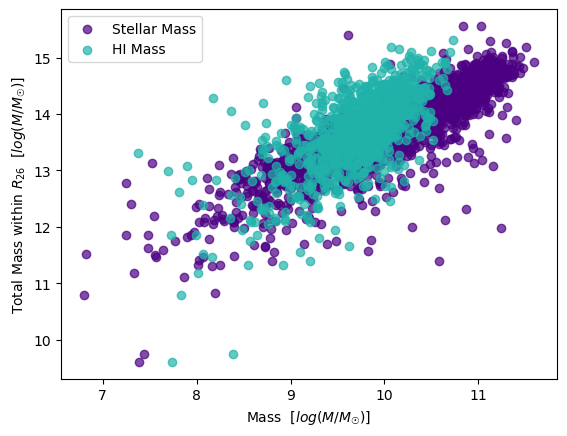

In [175]:
fig, ax = plt.subplots()

ax.scatter(total_stellar['log_cgmass'], total_stellar['total_mass'], alpha = .7, c = 'indigo')
ax.scatter(total_HI['logMH_alf'], total_HI['total_mass'], alpha = .7, c = 'lightseagreen')

# ax.scatter(test['log_cgmass'], test['logMH_alf'])
ax.legend(['Stellar Mass', 'HI Mass'])

ax.set_xlabel('Mass  $[log(M/M_☉)]$')
ax.set_ylabel('Total Mass within $R_{26}$  $[log(M/M_☉)]$')
# ax.set_title('Stellar/HI Mass vs $R_{26}$ $Mass$')

fig.savefig('/pscratch/sd/d/dbustos/for_poster/mass_plot', dpi=120)